# DQN baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms_discrete import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBufferDiscrete, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from networks import DQN_QNetwork


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env


[DQN] step=  10000 | eps=0.810 | eval_return=0.375 | eval_len=314.6
[DQN] step=  20000 | eps=0.620 | eval_return=0.500 | eval_len=255.1
[DQN] step=  30000 | eps=0.430 | eval_return=0.000 | eval_len=500.0
[DQN] step=  40000 | eps=0.240 | eval_return=0.625 | eval_len=190.6
[DQN] step=  50000 | eps=0.050 | eval_return=1.000 | eval_len=10.9
[DQN] step=  60000 | eps=0.050 | eval_return=1.000 | eval_len=8.4
[DQN] step=  70000 | eps=0.050 | eval_return=1.000 | eval_len=7.2
[DQN] step=  80000 | eps=0.050 | eval_return=0.875 | eval_len=71.2
[DQN] step=  90000 | eps=0.050 | eval_return=1.000 | eval_len=7.9
[DQN] step= 100000 | eps=0.050 | eval_return=1.000 | eval_len=11.2


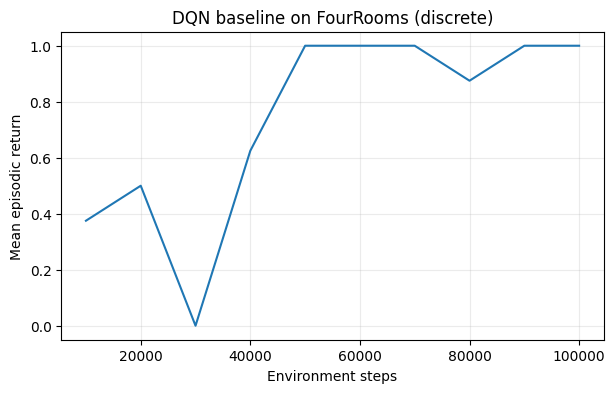

In [3]:
BUFFER_CAPACITY=100000
GOAL=(9, 9)
LR= float(1e-3)

env = make_env(goal=GOAL)
obs_dim = env.observation_space.shape[0]
num_actions = env.action_space.n

q_net = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target.load_state_dict(q_net.state_dict())
for p in q_target.parameters():
    p.requires_grad_(False)



def dqn_train(q_network=q_net, q_target_network=q_target, env=env, buffer_capacity=BUFFER_CAPACITY, lr=LR, obs_dim=obs_dim, device=DEVICE,
    total_steps=100000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=50000,
    train_freq=4,
):
    
    opt = optim.Adam(q_network.parameters(), lr=lr)
    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    obs, _ = env.reset()
    global_step = 0
    eval_returns = []

    ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = [], [], [], [], [], []

    while global_step < total_steps:
        # Epsilon-greedy action selection
        frac = min(1.0, global_step / eps_decay_steps)
        eps = eps_start + frac * (eps_end - eps_start)

        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                action = int(q_network(obs_t).argmax(dim=-1).item())

        next_obs, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        ep_obs.append(obs.copy())
        ep_actions.append(action)
        ep_rewards.append(float(rew))
        ep_next_obs.append(next_obs.copy())
        ep_terminated.append(float(term))
        ep_truncated.append(float(trunc))

        obs = next_obs
        global_step += 1

        if done:
            episode = {
                'obs': ep_obs,
                'actions': ep_actions,
                'rewards': ep_rewards,
                'next_obs': ep_next_obs,
                'terminated': ep_terminated,
                'truncated': ep_truncated,
            }
            buffer.add_episode(episode)
            ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = [], [], [], [], [], []
            obs, _ = env.reset()

        # Training update
        if len(buffer) >= warmup_steps and global_step % train_freq == 0:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs
            act_t = batch.actions.long()  # cast to int64 for use as gather indices
            rew_t = batch.rewards
            next_obs_t = batch.next_obs
            term_t = batch.terminated

            with torch.no_grad():
                next_q = q_target_network(next_obs_t).max(dim=-1, keepdim=True).values
                target = rew_t + gamma * (1.0 - term_t) * next_q

            current_q = q_network(obs_t).gather(1, act_t.unsqueeze(1))
            loss = F.mse_loss(current_q, target)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_network.parameters(), 10.0)
            opt.step()

            # Soft update target network
            for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        if global_step % 10000 == 0:
            eval_env = make_env()
            mean_ret, mean_len = evaluate_policy(
                eval_env,
                lambda o: int(
                    q_network(
                        torch.tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                    ).argmax(dim=-1).item()
                ),
                episodes=8,
            )
            eval_returns.append((global_step, mean_ret))
            print(f'[DQN] step={global_step:7d} | eps={eps:.3f} | eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}')
            eval_env.close()

    env.close()
    return q_network, eval_returns


dqn_q_first, dqn_eval_first = dqn_train()

if dqn_eval_first:
    xs, ys = zip(*dqn_eval_first)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('DQN baseline on FourRooms (discrete)')
    plt.grid(alpha=0.25)
    plt.show()


## Visualisations

Episode 1: 14 steps | return: 1.00 | reached goal: True
Episode 2: 12 steps | return: 1.00 | reached goal: True
Episode 3: 8 steps | return: 1.00 | reached goal: True
Episode 4: 9 steps | return: 1.00 | reached goal: True
Episode 5: 10 steps | return: 1.00 | reached goal: True
Episode 6: 10 steps | return: 1.00 | reached goal: True
Episode 7: 5 steps | return: 1.00 | reached goal: True
Episode 8: 1 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


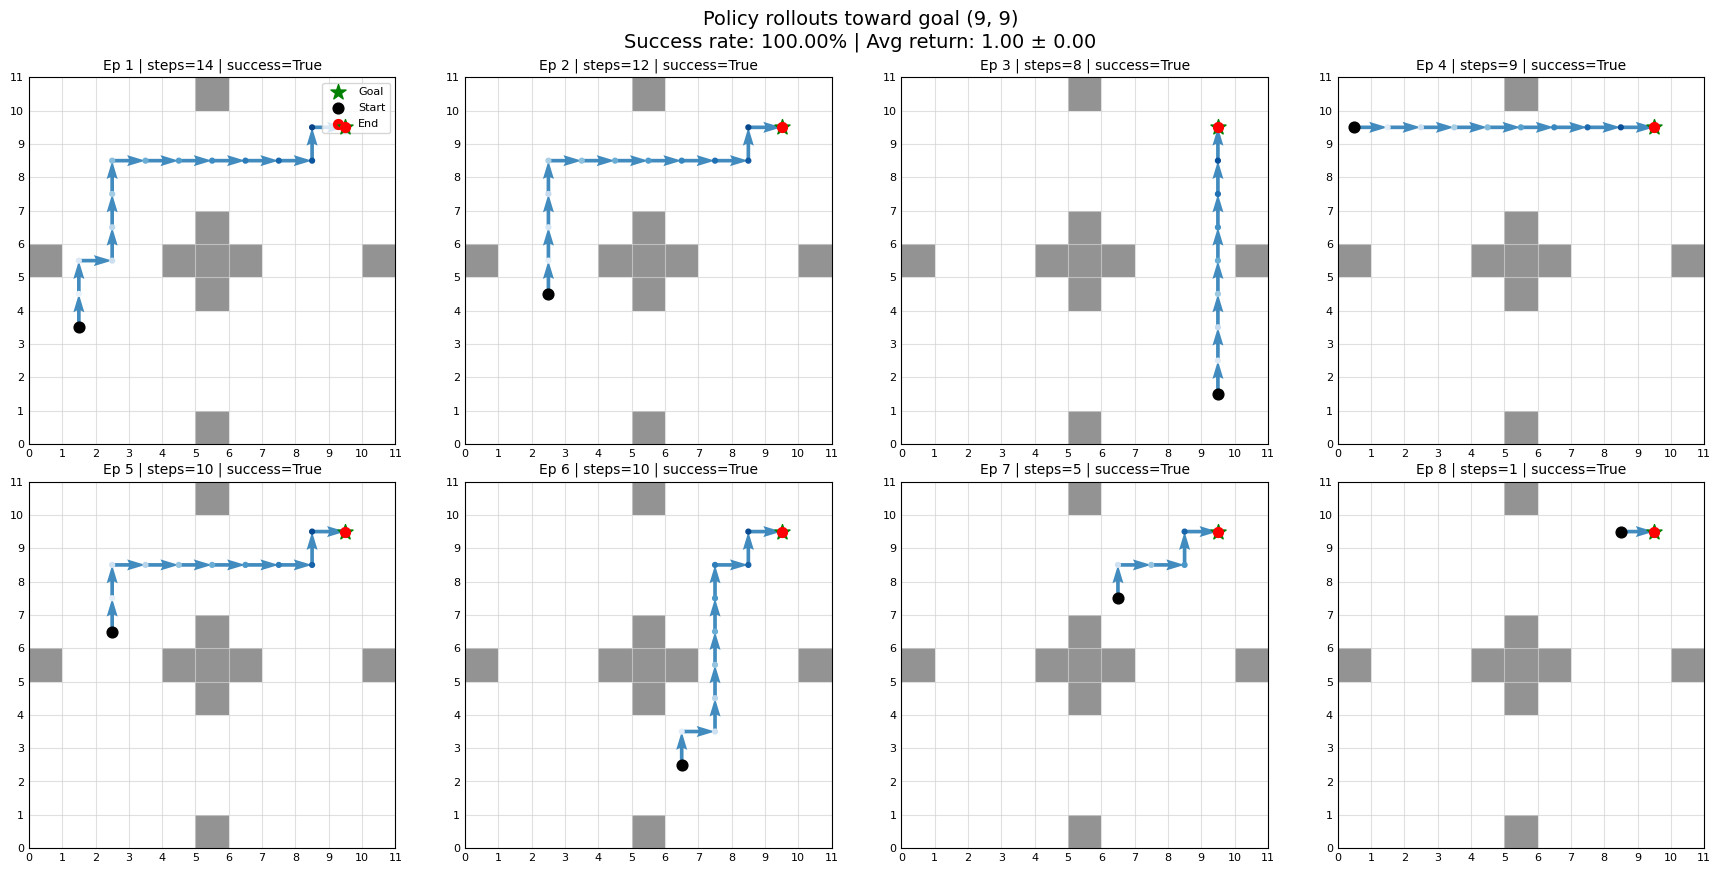

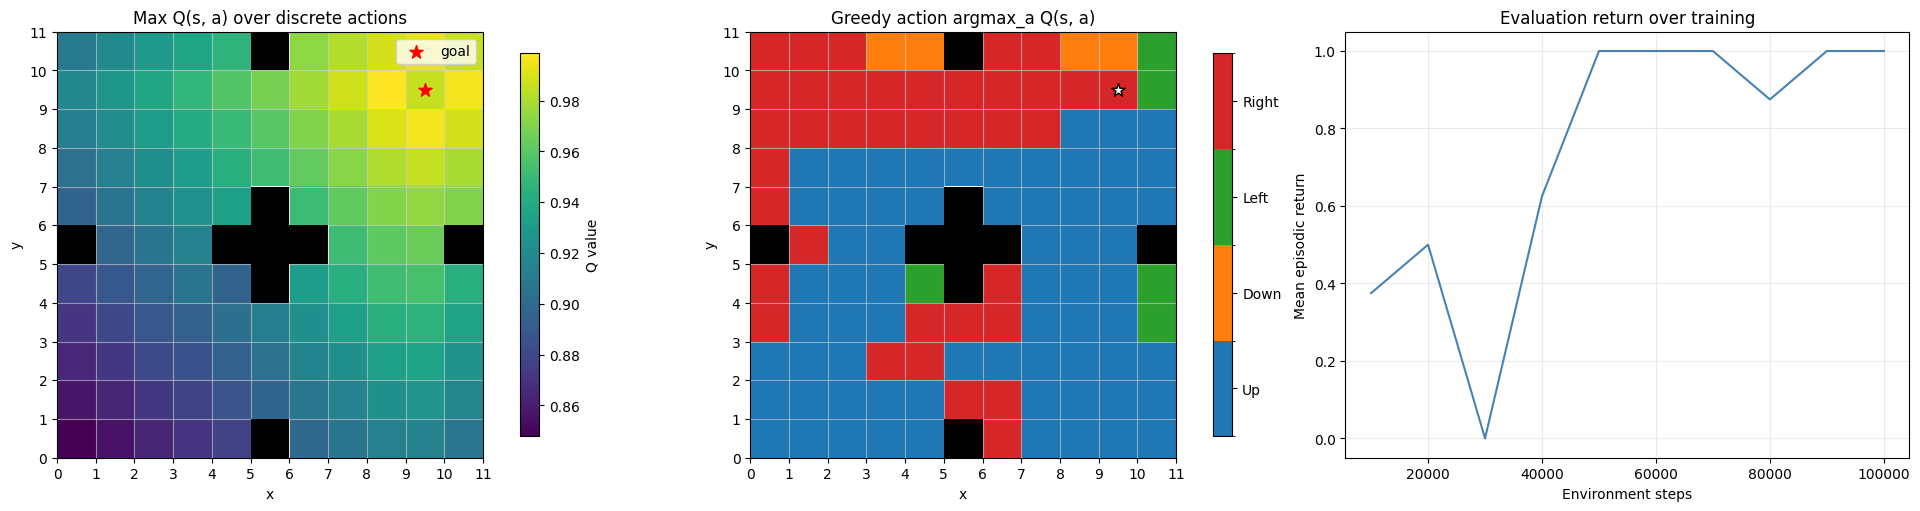

DQN_QNetwork(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)

In [4]:

dqn_q_first.eval()
eval_env_first = make_env(goal=(9, 9))


def dqn_policy_fn(obs,q_network):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        action = int(q_network(obs_t).argmax(dim=-1).item())
    return action


def dqn_value_fn(obs_batch, q_network):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        q_vals = q_network(obs_t).cpu().numpy()
    return q_vals


plot_policy_rollouts(
    env=eval_env_first,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_first),
    goal_pos=(9, 9),
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

eval_env_first.close()

eval_env_first = make_env(goal=(9, 9))

plot_q_diagnostics(
    env=eval_env_first,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_first),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=(9, 9),
    eval_returns=dqn_eval_first,
)

eval_env_first.close()

dqn_q_first.train()


## Now to check how much samples needed to reach a new goal

[DQN] step=  10000 | eps=0.810 | eval_return=0.000 | eval_len=500.0
[DQN] step=  20000 | eps=0.620 | eval_return=0.125 | eval_len=437.6
[DQN] step=  30000 | eps=0.430 | eval_return=0.000 | eval_len=500.0
[DQN] step=  40000 | eps=0.240 | eval_return=0.000 | eval_len=500.0
[DQN] step=  50000 | eps=0.050 | eval_return=0.000 | eval_len=500.0
[DQN] step=  60000 | eps=0.050 | eval_return=0.375 | eval_len=313.4
[DQN] step=  70000 | eps=0.050 | eval_return=0.000 | eval_len=500.0
[DQN] step=  80000 | eps=0.050 | eval_return=0.125 | eval_len=438.4
[DQN] step=  90000 | eps=0.050 | eval_return=0.000 | eval_len=500.0
[DQN] step= 100000 | eps=0.050 | eval_return=0.000 | eval_len=500.0


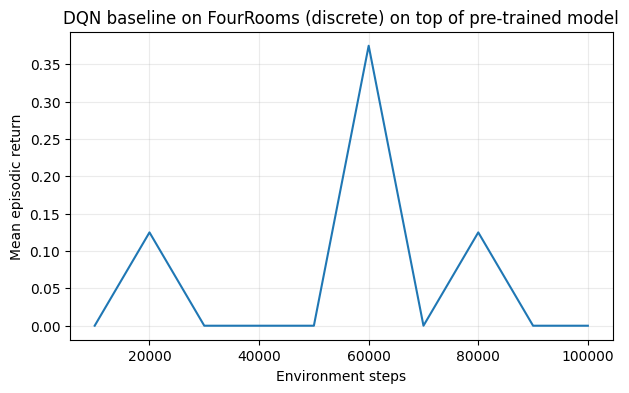

In [5]:
NEW_GOAL = (9, 1)

new_env = make_env(goal=NEW_GOAL)

q_target_new = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target_new.load_state_dict(q_net.state_dict())
for p in q_target_new.parameters():
    p.requires_grad_(False)

dqn_q_new, dqn_eval_new = dqn_train(env=new_env, q_network=dqn_q_first, q_target_network=q_target_new)

if dqn_eval_new:
    xs, ys = zip(*dqn_eval_new)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('DQN baseline on FourRooms (discrete) on top of pre-trained model')
    plt.grid(alpha=0.25)
    plt.show()


Episode 1: 8 steps | return: 1.00 | reached goal: True
Episode 2: 9 steps | return: 1.00 | reached goal: True
Episode 3: 10 steps | return: 1.00 | reached goal: True
Episode 4: 12 steps | return: 1.00 | reached goal: True
Episode 5: 9 steps | return: 1.00 | reached goal: True
Episode 6: 2 steps | return: 1.00 | reached goal: True
Episode 7: 8 steps | return: 1.00 | reached goal: True
Episode 8: 11 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


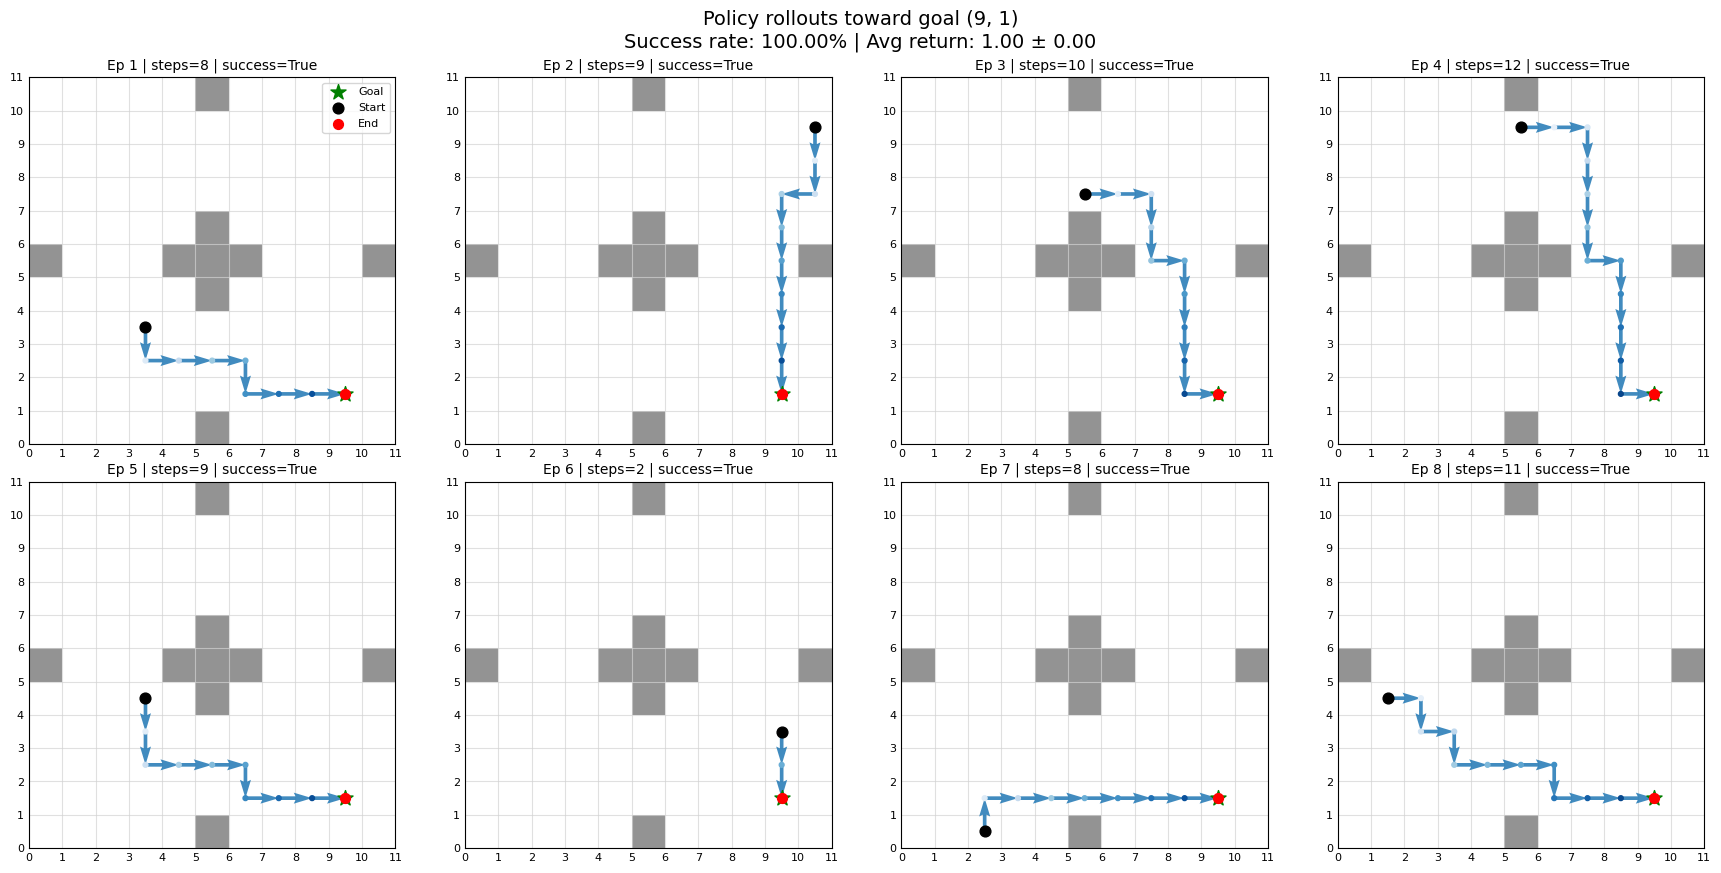

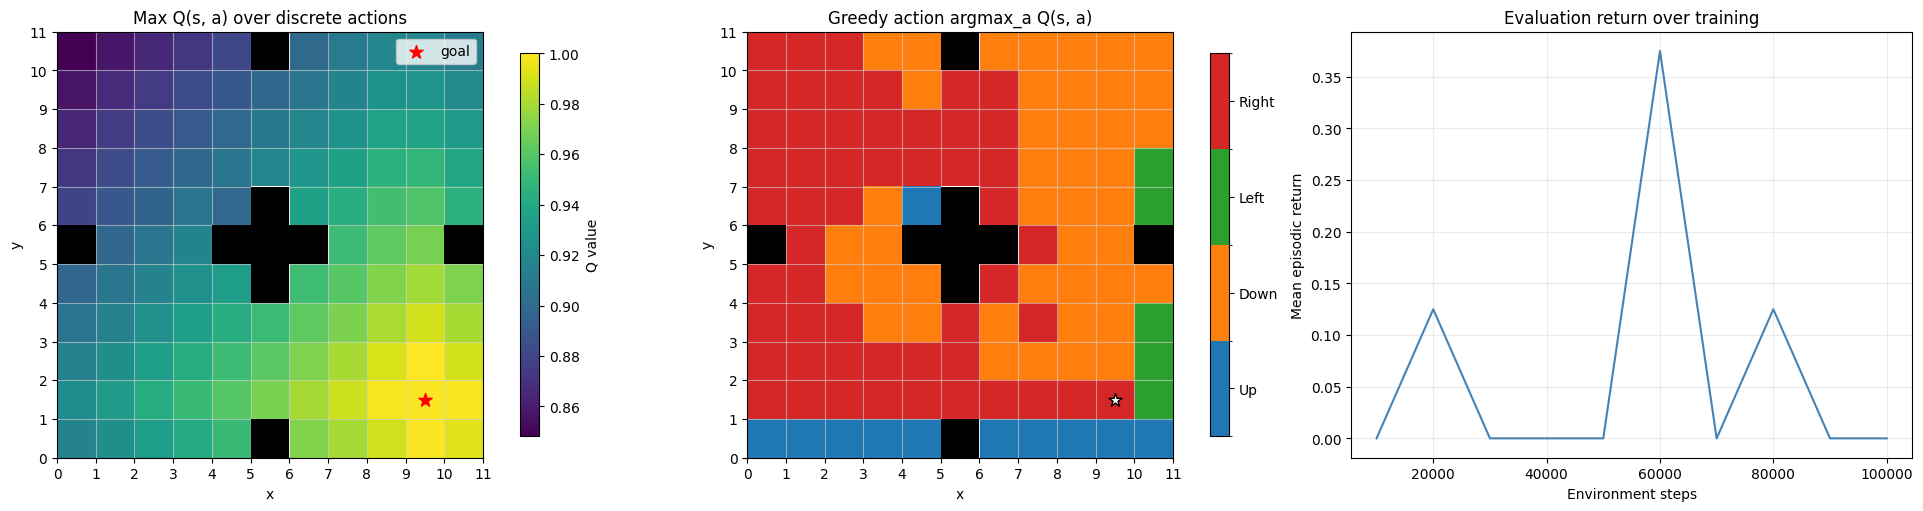

In [6]:

dqn_q_new.eval()
eval_env_new = make_env(goal=NEW_GOAL)


plot_policy_rollouts(
    env=eval_env_new,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_new),
    goal_pos=NEW_GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=eval_env_new,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_new),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=NEW_GOAL,
    eval_returns=dqn_eval_new,
)

eval_env_new.close()
